In [38]:
import pandas as pd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy


In [39]:
#Define QID - question matching -- ANES 2020
qids = ["V201324","V201416", "V202234", "V202257", "V202287", "V202332", "V202337", "V202348", "V202371", "V202378"]
name_dict = {"V201324" : "Current Economy", "V201416" : "Gay Marriage", "V202234" : "Refugee Allowing", 
            "V202257" : "Income Inequality", "V202287" : "Gender Role", "V202332": "Climate Change",
            "V202337": "Gun Regulation", "V202348": "Drug Addiction", "V202371": "Race Diversity", "V202378": "Health Insurance"}

def get_counts(path, qids): #function to get a dict with counts for each question
    value_list = []

    for id in qids:
        df = pd.read_csv(path + id + ".csv")
        df['Response'] = pd.to_numeric(df['Response'], errors='coerce') 

        value_counts = Counter(df['Response'].dropna())

        if id in ["V201324", "V202332"]:
            answers = {i: value_counts[i] for i in range(1, 6)}
        else:
            answers = {i: value_counts[i] for i in range(1, 4)}

        value_list.append({name_dict[id]: answers})

    return value_list


In [40]:
def get_human_counts(path, qids): #getting results from anes 2020
     anes_df = pd.read_csv(path)
     human_values = []

     for id in qids:
          human_counts = Counter(anes_df[id].dropna())

          if id in ["V201324", "V202332"]:
               answers = {i: human_counts[i] for i in range(1, 6)}
          else:
               answers = {i: human_counts[i] for i in range(1, 4)}

          human_values.append({name_dict[id]: answers})

     return human_values

human_results = get_human_counts("../data/2020 ANES_test.csv", qids)

/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_2552/955040501.py:2: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  anes_df = pd.read_csv(path)


In [41]:
def jsd_divergence_between_sets(set1, set2, base=2):

    jsd_results = {}

    dict1 = {list(d.keys())[0]: list(d.values())[0] for d in set1}
    dict2 = {list(d.keys())[0]: list(d.values())[0] for d in set2}

    for question in dict1.keys():
        if question not in dict2:
            continue 

        p_counts = dict1[question]
        q_counts = dict2[question]

        p = np.array([p_counts.get(k, 0) for k in p_counts], dtype=float)
        q = np.array([q_counts.get(k, 0) for k in p_counts], dtype=float)

        p /= p.sum()
        q /= q.sum()

        epsilon = 1e-10
        p = np.clip(p, epsilon, 1)
        q = np.clip(q, epsilon, 1)

        m = 0.5 * (p + q)
        jsd_pq = 0.5 * (entropy(p, m, base=base) + entropy(q, m, base=base)) 
        jsd_results[question] = jsd_pq

    return jsd_results


In [42]:
def plot_replicate_stacked_w_JSD(human_results, silicon_results, jsd_results1,
          model='GPT-4.1', output_path=''):

    categories = [
        'Climate Change', 'Current Economy', 'Refugee Allowing', 'Health Insurance',
        'Income Inequality', 'Race Diversity', 'Drug Addiction',
        'Gay Marriage', 'Gun Regulation', 'Gender Role'
    ]

    x = np.arange(len(categories))

    human_dict = {list(d.keys())[0]: list(d.values())[0] for d in human_results}
    silicon_dict = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results}

    human_stack = []
    silicon_stack = []
    jsd1 = []

    # --- Build stacked distributions for each category ---
    for question in categories:
        h_dist = np.array(list(human_dict[question].values()), dtype=float)
        s_dist = np.array(list(silicon_dict[question].values()), dtype=float)

        h_dist /= h_dist.sum()
        s_dist /= s_dist.sum()

        human_stack.append(h_dist)
        silicon_stack.append(s_dist)

        jsd1.append(jsd_results1[question])

    human_colors = [
        (0.12, 0.47, 0.71, 1.0),
        (0.20, 0.63, 0.17, 1.0),
        (0.96, 0.73, 0.07, 1.0),
        (1.0, 0.50, 0.0, 1.0),
        (0.78, 0.24, 0.24, 1.0),
    ]

    silicon_colors = [
        (0.12, 0.47, 0.71, 0.45),
        (0.20, 0.63, 0.17, 0.45),
        (0.96, 0.73, 0.07, 0.45),
        (1.0, 0.50, 0.0, 0.45),
        (0.78, 0.24, 0.24, 0.45),
    ]

    fig, ax1 = plt.subplots(figsize=(5.2, 4))
    bar_width = 0.35

    # --- Plot stacked Human bars ---
    for idx, dist in enumerate(human_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] - bar_width/2,
                val,
                width=bar_width,
                bottom=bottom,
                color=human_colors[i],
                label='Human (Darker colors)' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    # --- Plot stacked Silicon bars ---
    for idx, dist in enumerate(silicon_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] + bar_width/2,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors[i],
                label='Silicon (Lighter colors)' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    # --- Axes ---
    ax1.set_ylabel('Response rate')
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=45, ha='right')
    ax1.set_ylim(0, 1.)
    ax1.set_xmargin(0.00)

    ax1.set_xlabel('')
    # ax1.legend(loc='upper left', ncol=1, frameon=True, bbox_to_anchor=(0, 1.22))
    ax1.legend(loc='upper left', ncol=1, frameon=False, bbox_to_anchor=(-0.04, 1.25))

    # --- JSD lines on secondary axis ---
    ax2 = ax1.twinx()
    ax2.plot(
        x+bar_width/2, jsd1,
        color='black', marker='D', markerfacecolor='none',
        markersize=9, linewidth=2, markeredgewidth=2,linestyle='-',
        label=f'JSD {model}'
    )

    ax2.set_ylabel('JS-divergence (JSD)')
    ax2.set_ylim(0, 0.5)
    ax2.set_xmargin(0.00)

    # --- JSD legend ---
    ax2.legend(loc='upper right', frameon=False, bbox_to_anchor=(1.07, 1.2))
    plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
    # --- Remove figure box / spines ---
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)   # optional
    ax1.spines['left'].set_visible(False)     # optional

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)   # optional
    ax2.spines['left'].set_visible(False)     # optional

    # ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()

    # ----- Save figure as compact PDF -----
    if output_path != '':
        fig.savefig(
            output_path,
            format="pdf",
            bbox_inches="tight",     # removes extra margins
            pad_inches=0.05,         # small padding
            dpi=300                  # high quality
        )
        print(f"Saved figure to {output_path}")


Saved figure to replicate-gpt4.1-alone-small-stoc.pdf


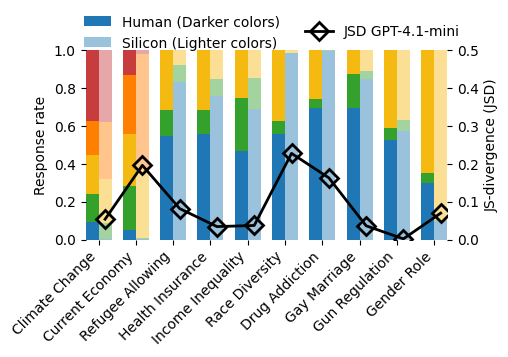

In [7]:
# GPT-4.1
replicate_results = get_counts("../Publication Results/Gpt4.1-Mini/main_mq_results/full_results_2020_", qids)

jsd_results_replicate = jsd_divergence_between_sets(human_results, replicate_results, base=2)
jsd_results_replicate_gpt = jsd_results_replicate
plot_replicate_stacked_w_JSD(human_results, replicate_results, jsd_results_replicate,
                       'GPT-4.1-mini',  'replicate-gpt4.1-alone-small-stoc.pdf')

Saved figure to replicate-llama8b-alone-small-stoc.pdf


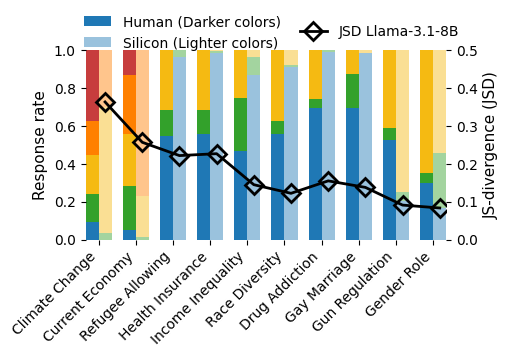

In [8]:
# LLama 3.1 8b
replicate_results = get_counts("../Publication Results/8B-Llama-Stochastic/main_mq_results/full_results_2020_", qids)

jsd_results_replicate = jsd_divergence_between_sets(human_results, replicate_results, base=2)
jsd_results_replicate_8b = jsd_results_replicate
plot_replicate_stacked_w_JSD(human_results, replicate_results, jsd_results_replicate,
                       'Llama-3.1-8B',  'replicate-llama8b-alone-small-stoc.pdf')

Saved figure to replicate-llama70b-alone-small-stoc.pdf


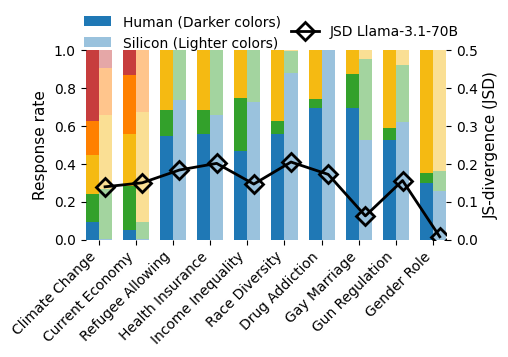

In [9]:
# LLama 3.1 70b
replicate_results = get_counts("../Publication Results/3170B-Llama-Stochastic/main_mq_results/full_results_2020_", qids)

jsd_results_replicate = jsd_divergence_between_sets(human_results, replicate_results, base=2)
jsd_results_replicate_70b = jsd_results_replicate
plot_replicate_stacked_w_JSD(human_results, replicate_results, jsd_results_replicate,
                       'Llama-3.1-70B',  'replicate-llama70b-alone-small-stoc.pdf')

In [43]:

jsd = {
    question: [
        float(jsd_results_replicate_8b[question]),
        float(jsd_results_replicate_70b[question]),
        float(jsd_results_replicate_gpt[question]),
    ]
    for question in jsd_results_replicate_70b
}

In [44]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)


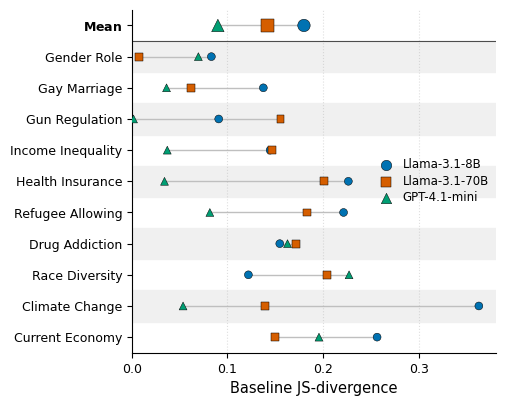

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    # "font.family": "serif",
    # "font.serif": ["Nimbus Roman", "Times New Roman", "DejaVu Serif"],
    # "mathtext.fontset": "cm",
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

models  = ["Llama-3.1-8B", "Llama-3.1-70B", "GPT-4.1-mini"]
markers = ["o", "s", "^"]
colors  = ["#0072B2", "#D55E00", "#009E73"]

items = sorted(jsd, key=lambda q: np.mean(jsd[q]))
means_per_model = [np.mean([jsd[q][m] for q in items]) for m in range(3)]

rows = ["Mean (all items)"] + items
data = {"Mean (all items)": means_per_model, **{q: jsd[q] for q in items}}
y = np.arange(len(rows))[::-1]
item_y = list(zip(items, y[1:]))

# narrower + shorter, so it sits comfortably next to a table
fig, ax = plt.subplots(figsize=(5, 4.0))

for i, (q, yi) in enumerate(item_y):
    if i % 2 == 0:
        ax.axhspan(yi - 0.5, yi + 0.5, color="0.94", zorder=0)

sep_y = (y[0] + y[1]) / 2
ax.axhline(sep_y, color="0.3", lw=0.8, zorder=2)

for row, yi in zip(rows, y):
    lo, hi = min(data[row]), max(data[row])
    ax.plot([lo, hi], [yi, yi], color="0.75", lw=1, zorder=1)

for m, (name, mk, c) in enumerate(zip(models, markers, colors)):
    xs = [data[row][m] for row in rows]
    sizes = [80 if row == "Mean (all items)" else 32 for row in rows]
    ax.scatter(xs, y, marker=mk, s=sizes, facecolor=c, edgecolor="black",
               linewidth=0.35, label=name, zorder=3)

ax.set_yticks(y)
ylabels = [r"$\mathbf{Mean}$" if r == "Mean (all items)" else r for r in rows]
ax.set_yticklabels(ylabels)
ax.set_xlabel("Baseline JS-divergence")
ax.set_xlim(left=0)
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.grid(axis="x", ls=":", alpha=0.4, zorder=0)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="center right", handletextpad=0.4,
          borderaxespad=0.2, labelspacing=0.3)
fig.tight_layout(pad=0.5)
plt.show()
# fig.savefig("baseline_jsd.pdf", format="pdf", bbox_inches="tight")
# plt.close(fig)